
 A5 — Simple Exponential Smoothing (SES)

In this notebook, we apply **Simple Exponential Smoothing (SES)** to the monthly passenger traffic series for JFK airport.

 Objective
The main goal is to forecast future values by giving more weight to recent observations while still considering older observations.

 Why SES?
Simple Exponential Smoothing is suitable for time series that do **not** have a strong trend or seasonality. It is a basic smoothing and forecasting method that works well as a benchmark model.

Method Logic

Simple Exponential Smoothing updates forecasts using past observations, with exponentially decreasing weights over time.

This means:
- recent values are more important,
- older values still affect the forecast,
- the effect of older values becomes smaller and smaller.

SES is generally used for relatively stable series without clear trend or seasonality.

 Imports

We import the required libraries for:
- data handling,
- visualization,
- and Simple Exponential Smoothing modeling.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

 Importing Libraries

We import the necessary libraries for data handling, visualization, and time series modeling.

In [42]:
# Load the dataset 
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

# filtered JFK observation 
df_jfk = df[df['Airport Code'] == 'JFK'].copy()

df_jfk.head(10)

,Airport Code,Year,Month,Domestic Passengers,International Passengers,Total Passengers
516,JFK,2015,Jan,1891156,2060967,3952123
517,JFK,2015,Feb,1806434,1718574,3525008
518,JFK,2015,Mar,2209055,2208031,4417086
519,JFK,2015,Apr,2252631,2381501,4634132
520,JFK,2015,May,2359873,2605811,4965684
521,JFK,2015,Jun,2380699,2773121,5153820
522,JFK,2015,Jul,2530151,3117712,5647863
523,JFK,2015,Aug,2535971,3273753,5809724
524,JFK,2015,Sep,2134468,2647629,4782097
525,JFK,2015,Oct,2328298,2571768,4900066


In [43]:
df_jfk['Month'].unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In [44]:
# Map month names to manth number
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df_jfk['Month_num'] = df_jfk['Month'].map(month_map)


 Creating Datetime Variable

The dataset contains separate `Year` and `Month` columns.  
To perform time series analysis, we combine these into a single datetime column.

We set the day as the first of each month to create a proper monthly time index.

In [45]:

df_jfk['Date'] = pd.to_datetime(
    df_jfk['Year'].astype(str) + '-' + df_jfk['Month_num'].astype(str) + '-01'
)

df_jfk[['Year', 'Month', 'Date']].head(10)

,Year,Month,Date
516,2015,Jan,2015-01-01
517,2015,Feb,2015-02-01
518,2015,Mar,2015-03-01
519,2015,Apr,2015-04-01
520,2015,May,2015-05-01
521,2015,Jun,2015-06-01
522,2015,Jul,2015-07-01
523,2015,Aug,2015-08-01
524,2015,Sep,2015-09-01
525,2015,Oct,2015-10-01


In [46]:
df.columns

Index(['Airport Code', 'Year', 'Month', 'Domestic Passengers',
       'International Passengers', 'Total Passengers'],
      dtype='object')

 Creating the Time Series

We aggregate the total number of passengers on a monthly basis and create a time series.

This ensures:
- a unique datetime index,
- correct chronological order,
- and readiness for forecasting models.

In [47]:
ts = df_jfk.groupby('Date')['Total Passengers'].sum().sort_index()

ts.head(10)

Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
1977-06-01    1906396
1977-07-01    2373334
1977-08-01    2372987
1977-09-01    2010979
1977-10-01    1806198
Name: Total Passengers, dtype: int64

 Checking the Time Series

We verify that:
- the index is datetime-based,
- the series is sorted,
- and there are no missing values.

In [48]:
print(ts.index)


DatetimeIndex(['1977-01-01', '1977-02-01', '1977-03-01', '1977-04-01',
               '1977-05-01', '1977-06-01', '1977-07-01', '1977-08-01',
               '1977-09-01', '1977-10-01',
               ...
               '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01',
               '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01',
               '2015-11-01', '2015-12-01'],
              dtype='datetime64[ns]', name='Date', length=468, freq=None)


In [49]:
ts.isna().sum()

np.int64(0)

## Time Series Visualization

Before applying Simple Exponential Smoothing, we first visualize the monthly total passenger series.

This helps us understand whether the series is relatively stable or whether it contains visible trend and seasonal patterns.

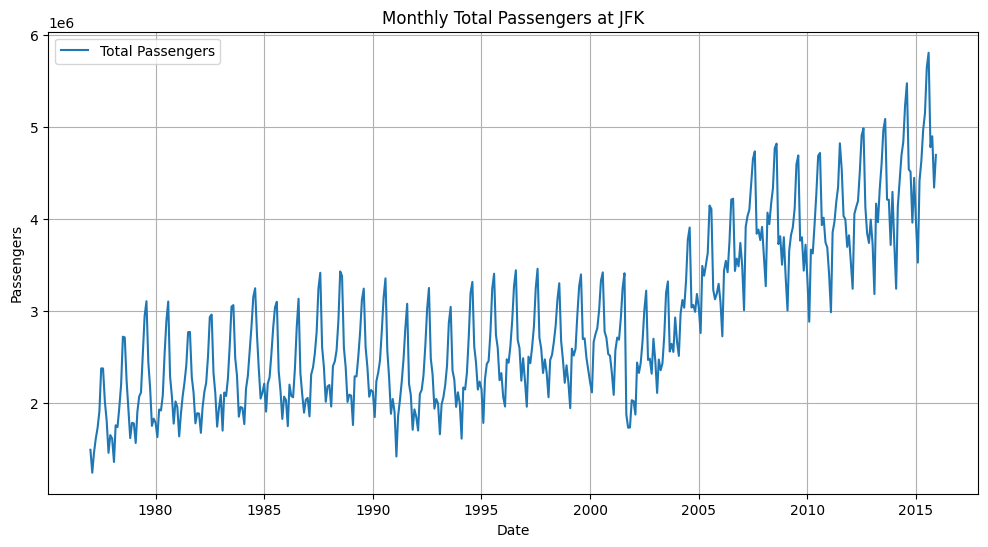

In [50]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Total Passengers')
plt.title('Monthly Total Passengers at JFK')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()


## Initial Interpretation

The plot allows us to visually inspect the structure of the series.

Although Simple Exponential Smoothing is mainly suitable for series without strong trend or seasonality, it can still be used as a basic smoothing and benchmark forecasting method.

In this project, SES is applied to understand how weighted smoothing behaves on the JFK passenger series and to provide a simple baseline forecast.

In [51]:
ts.describe()

count    4.680000e+02
mean     2.851086e+06
std      8.957019e+05
min      1.237719e+06
25%      2.139222e+06
50%      2.604570e+06
75%      3.418891e+06
max      5.809724e+06
Name: Total Passengers, dtype: float64

The series shows the overall level and variation of monthly passenger traffic over time. At this stage, SES will help smooth short-term fluctuations by assigning more weight to recent observations.

Suitability of SES

From the plot, we observe that the series exhibits:
- an increasing trend over time,
- strong seasonal patterns.

Simple Exponential Smoothing is not ideal for such series, as it does not explicitly model trend or seasonality.

However, SES is still applied in this analysis as:
- a baseline model,
- and to demonstrate how exponential smoothing behaves on real-world data.

In [52]:
model = SimpleExpSmoothing(ts)
model_fit = model.fit()

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


 Model Fitting

The model is fitted to the time series.

By default, the smoothing parameter (alpha) is automatically optimized to best fit the data.

In [53]:
fitted_model = model_fit.fittedvalues

In [54]:
forecast = model_fit.forecast(12)

Forecasting

We generate forecasts for the next 12 months using the fitted SES model.

Since SES does not model trend or seasonality, the forecast is expected to follow a relatively flat pattern.

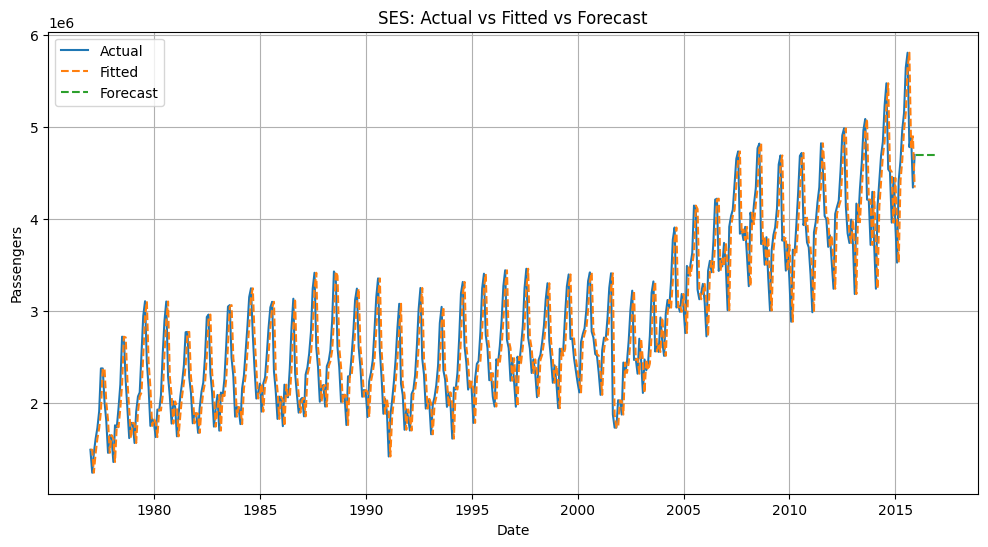

In [56]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual')
plt.plot(fitted_model, label='Fitted', linestyle='--')
plt.plot(forecast, label='Forecast', linestyle='--')

plt.title('SES: Actual vs Fitted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

 Interpretation

The SES model smooths the series by reducing short-term fluctuations.

However:
- it fails to capture the upward trend,
- and it does not reproduce the seasonal patterns.

The forecast remains relatively flat, which highlights a key limitation of SES when applied to data with trend and seasonality.

This suggests that more advanced models (such as Holt or Holt-Winters) would be more appropriate for this dataset.

Effect of Smoothing Parameter (Alpha)

The smoothing parameter (alpha) controls how much weight is given to recent observations.

- Higher alpha → more responsive to recent changes  
- Lower alpha → smoother, more stable forecasts  

We will test different alpha values to observe how the model behavior changes.

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


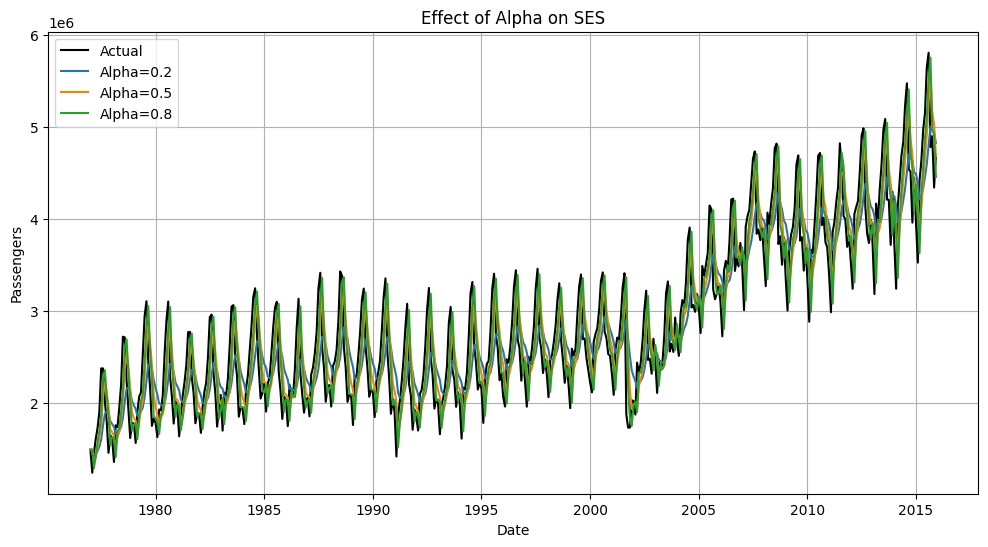

In [ ]:
alphas = (0.2, 0.5, 0.8)

plt.figure(figsize=(12,6))

plt.plot(ts, label='Actual', color='black')

for alpha in alphas:
    model = SimpleExpSmoothing(ts)
    model_fit = model.fit(smoothing_level=alpha, optimized=False)

    fitted = model_fit.fittedvalues
    plt.plot(fitted, label=f'Alpha={alpha}')

plt.title('Effect of Alpha on SES')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Alpha Effects

Different alpha values significantly impact how the model reacts to the data:

- **Low alpha (0.2):**
  Produces a very smooth curve that reacts slowly to changes.
  
- **Medium alpha (0.5):**
  Balances between smoothness and responsiveness.
  
- **High alpha (0.8):**
  Reacts quickly to recent changes but may introduce more volatility.

This demonstrates how SES can be tuned depending on whether we prioritize stability or responsiveness.

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


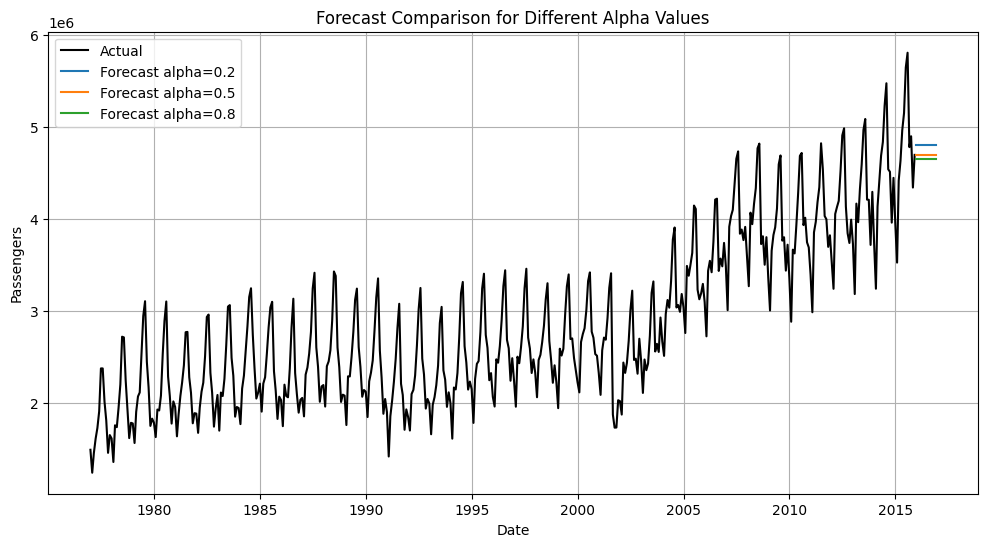

In [68]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')

for alpha in alphas:
    model = SimpleExpSmoothing(ts)
    model_fit = model.fit(smoothing_level=alpha, optimized=False)

    forecast = model_fit.forecast(12) 

    plt.plot(forecast.index, forecast.values, label=f'Forecast alpha={alpha}')

plt.title('Forecast Comparison for Different Alpha Values')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

Zoomed Forecast View

To better compare the forecasts, we zoom in on the final part of the series and the 12-month forecast horizon.

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


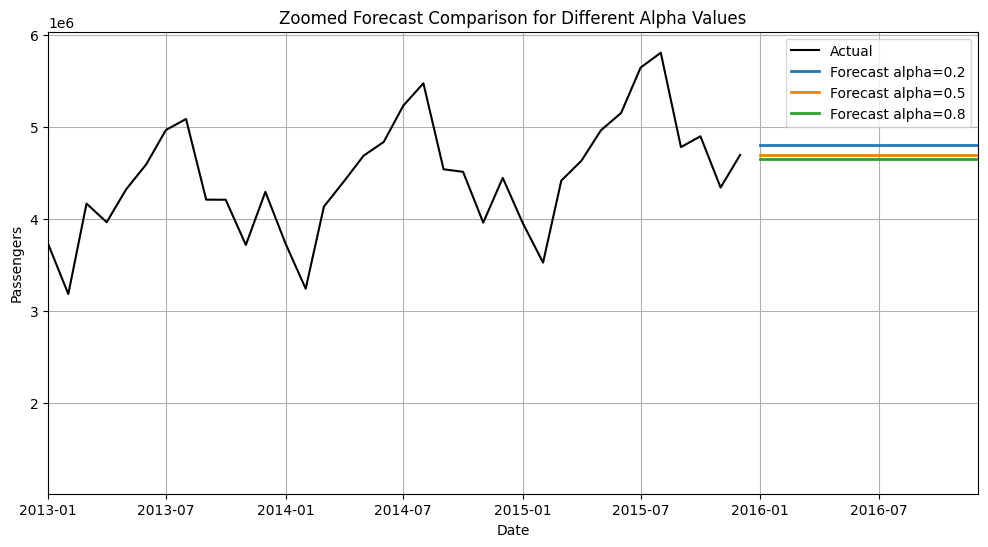

In [69]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')

for alpha in alphas:
    model = SimpleExpSmoothing(ts)
    model_fit = model.fit(smoothing_level=alpha, optimized=False)
    forecast = model_fit.forecast(12)

    plt.plot(forecast.index, forecast.values, label=f'Forecast alpha={alpha}', linewidth=2)

plt.title('Zoomed Forecast Comparison for Different Alpha Values')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)

plt.xlim(ts.index[-36], forecast.index[-1])
plt.show()